In [ ]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 14.5 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import pygame
import sys
from IPython.display import clear_output
import time
import matplotlib.pyplot as plt

In [ ]:

class ChipGameEnv(gym.Env):
    def __init__(self):
        super(ChipGameEnv, self).__init__()

        self.num_players = 4
        self.player_letters = ['A', 'B', 'C', 'D']
        self.max_chips = 5
        self.num_rows = 6
        self.done = False

        # Constants for rendering
        self.SCREEN_WIDTH = 800
        self.SCREEN_HEIGHT = 700
        self.ROW_HEIGHT = (1/self.num_rows) * 550
        self.PLAYER_COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
        self.BACKGROUND_COLOR = (125, 125, 125)

        # Action and observation spaces
        self.action_space = spaces.Discrete(self.num_rows + 4)
        # Calculate the total observation space size
        max_pile_size = self.num_players * self.max_chips
        total_obs_size = (
            self.num_rows * self.num_players * max_pile_size +  # Board state
            self.num_players * self.num_players +  # Player chips
            self.num_players +  # Dead chips
            self.num_players +  # Current player
            4 +  # Game state (assuming 4 possible states)
            1  # Steps
        )

        self.observation_space = spaces.Box(low=0, high=max(self.max_chips, max_pile_size),
                                            shape=(total_obs_size,), dtype=np.int32)

        # Initialize Pygame for rendering
        pygame.init()
        print("Pygame initialized")
        # self.screen = pygame.display.set_mode((self.SCREEN_WIDTH, self.SCREEN_HEIGHT))
        pygame.display.set_caption("Chip Game")
        self.clock = pygame.time.Clock()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.players = [self._create_player(letter) for letter in self.player_letters]
        self.current_player_index = random.randint(0, self.num_players - 1)
        self.rows = [[] for _ in range(self.num_rows)]
        self.state = "choose_pile"
        self.last_played_row = None
        self.turn_history = [self.players[0]]
        self.eligible_next_players = []
        self.done = False
        self.steps_num = 0

        observation = self._get_obs()
        info = {}
        return observation, info

    @staticmethod
    def reward_fn(reward, chips, steps):
        beta = 50
        alpha = 15/(chips*beta)
        return min(reward, reward/(alpha*steps))


    def step(self, action):
        info = {}
        winner = None
        step_log = []
        step_rewards = {player.letter: 0 for player in self.players}  # Track rewards for each player

        if self.done:
            step_log.append("Game is already over. No more actions can be taken.\n")
            observation = self._get_obs()
            info['winner'] = winner
            info['log'] = step_log
            return observation, 0, self.done, False, info

        self.steps_num += 1

        if self.state == "choose_pile":
            if 0 <= action < self.num_rows:
                self.last_played_row = action
                if self._current_player().has_only_one_chip_type():
                    if self._play_chip(self.last_played_row, self._current_player().get_only_chip_type()):
                        self._current_player().reward += self.reward_fn(5, self.max_chips, self.steps_num)  # Reward for successful chip placement
                        step_rewards[self._current_player().letter] += self.reward_fn(5, self.max_chips, self.steps_num)
                    else:
                        self._current_player().reward -= 5  # Invalid action penalty
                        step_rewards[self._current_player().letter] -= 5
                else:
                    self.state = "choose_chip"
            else:
                self._current_player().reward -= 5  # Invalid action penalty
                step_rewards[self._current_player().letter] -= 5

        elif self.state == "choose_chip":
            if self.num_rows <= action < self.num_rows + 4:
                chip_letter = self.player_letters[action - self.num_rows]
                if self._play_chip(self.last_played_row, chip_letter):
                    self._current_player().reward += self.reward_fn(5, self.max_chips, self.steps_num)  # Reward for successful chip placement
                    step_rewards[self._current_player().letter] += self.reward_fn(5, self.max_chips, self.steps_num)
                else:
                    self._current_player().reward -= 5  # Invalid action penalty
                    step_rewards[self._current_player().letter] -= 5
            else:
                self._current_player().reward -= 5  # Invalid action penalty
                step_rewards[self._current_player().letter] -= 5

        elif self.state == "choose_next_player":
            if self.num_rows <= action < self.num_rows + 4:
                next_player_letter = self.player_letters[action - self.num_rows]
                if self._choose_next_player(next_player_letter):
                    self._current_player().reward += self.reward_fn(5, self.max_chips, self.steps_num)  # Small reward for choosing next player
                    step_rewards[self._current_player().letter] += self.reward_fn(5, self.max_chips, self.steps_num)
                    self.state = "choose_pile"
                else:
                    self._current_player().reward -= 5  # Invalid action penalty
                    step_rewards[self._current_player().letter] -= 5
            else:
                self._current_player().reward -= 5  # Invalid action penalty
                step_rewards[self._current_player().letter] -= 5

        elif self.state == "eliminate_chip":
            if self.num_rows <= action < self.num_rows + 4:
                chip_to_eliminate = self.player_letters[action - self.num_rows]
                if self._eliminate_chip(chip_to_eliminate):
                    self._current_player().reward += self.reward_fn(5, self.max_chips, self.steps_num)  # Reward for successful chip elimination
                    step_rewards[self._current_player().letter] += self.reward_fn(5, self.max_chips, self.steps_num)
                    self.state = "choose_pile"
                else:
                    self._current_player().reward -= 5  # Invalid action penalty
                    step_rewards[self._current_player().letter] -= 5
            else:
                self._current_player().reward -= 5  # Invalid action penalty
                step_rewards[self._current_player().letter] -= 5
        else:
            self._current_player().reward -= 5  # Invalid action penalty
            step_rewards[self._current_player().letter] -= 5



        # step_log.append(f"Current Player: {self._current_player().letter}\n")
        # step_log.append(f"Current State: {self.state}\n")
        # step_log.append(f"Action: {action}\n")
        # step_log.append(f"Last Played Row: {self.last_played_row}\n")
        # step_log.append(f"Turn History: {[player.letter for player in self.turn_history]}\n")
        # step_log.append(f"Active Players: {self._count_active_players()}\n")
        # step_log.append(f"Rows: {self.rows}\n")

        # for player in self.players:
        #     step_log.append(f"{player.letter}:\n")
        #     for letter, count in player.chips.items():
        #         step_log.append(f"  {letter}: {count}\n")
        #     step_log.append(f"Dead Chips: {player.dead_chips}\n")
        #     step_log.append("\n")

        # Update player rewards and track step rewards
        for player in self.players:
            step_rewards[player.letter] = player.reward
            player.reward = 0  # Reset for next step



        if self.is_game_over():
            self.done = True
            steps_num = 0
            step_log.append("Game Over Condition Met\n")
            winner = next((player for player in self.players if not player.eliminated), None)
            if winner:
                winner.reward += 15
                step_rewards[winner.letter] += 15
                step_log.append(f"Winner ({winner.letter}) reward: 10\n")

        observation = self._get_obs()
        info['winner'] = winner
        info['log'] = step_log

        return observation, step_rewards, self.done, False, info




    def _get_obs(self):
        max_pile_size = self.num_players * self.max_chips
        total_obs_size = (
            self.num_rows * self.num_players * max_pile_size +  # Board state
            self.num_players * self.num_players +  # Player chips
            self.num_players +  # Dead chips
            self.num_players +  # Current player
            4 +  # Game state (assuming 4 possible states)
            1  # Steps
        )

        obs = np.zeros(total_obs_size, dtype=np.int32)

        # Board state
        for i, row in enumerate(self.rows):
            for j, chip in enumerate(row):
                if j < max_pile_size:
                    obs[i * self.num_players * max_pile_size + self.player_letters.index(chip) * max_pile_size + j] = 1

        # Player chips
        offset = self.num_rows * self.num_players * max_pile_size
        for i, player in enumerate(self.players):
            for j, letter in enumerate(self.player_letters):
                obs[offset + i * self.num_players + j] = player.chips[letter]

        # Dead chips
        offset += self.num_players * self.num_players
        for i, player in enumerate(self.players):
            obs[offset + i] = player.dead_chips

        # Current player
        offset += self.num_players
        obs[offset + self.current_player_index] = 1

        # Game state
        offset += self.num_players
        state_index = ["choose_pile", "choose_chip", "choose_next_player", "eliminate_chip"].index(self.state)
        obs[offset + state_index] = 1

        # The number of steps that have happened in the game
        offset += 4
        obs[offset] = self.steps_num

        return obs

    def _create_player(self, letter):
        return self.Player(letter, self.max_chips, self.player_letters)

    def _current_player(self):
        return self.players[self.current_player_index]

    def _play_chip(self, row, chip_letter):
        if 0 <= row < self.num_rows and self._current_player().chips[chip_letter] > 0:
            self.rows[row].append(chip_letter)
            self._current_player().chips[chip_letter] -= 1
            self.last_played_row = row
            if self._check_capture(row):
                benefitting_player = next((p for p in self.players if p.letter == chip_letter), None)
                if benefitting_player and not benefitting_player.eliminated: #do this only if capturing colored player is not eliminated otherwise entire pile is deadzoned
                    self.current_player_index = self.players.index(next(p for p in self.players if p.letter == chip_letter) )
                    self.state = "eliminate_chip"
                else:   #deadzone entire pile
                    for chip in self.rows[self.last_played_row]:
                        player = next((p for p in self.players if p.letter == chip), None)
                        if player:
                            player.dead_chips += 1
                    self.rows[self.last_played_row] = []
                    if self._current_player().count_total_chips() == 0:
                        self._check_player_elimination()
                    self.state = "choose_pile"
            else:
                self._determine_next_players()
            return True
        return False

    def _check_capture(self, row):
        played_pile = self.rows[row]
        return len(played_pile) > 1 and played_pile[-1] == played_pile[-2]

    def _determine_next_players(self):
        played_pile = self.rows[self.last_played_row]
        active_players = [p for p in self.players if not p.eliminated]
        active_player_letters = [p.letter for p in active_players]
        colors_in_pile = [color for color in set(played_pile) if not next(player.eliminated for player in self.players if player.letter == color)]

        if sorted(colors_in_pile) == sorted(active_player_letters):
            last_appearances = {color: len(played_pile) - 1 - played_pile[::-1].index(color)
                                for color in colors_in_pile}
            next_player_letter = min(last_appearances, key=last_appearances.get)
            self._set_next_player(next(p for p in active_players if p.letter == next_player_letter))
            self.state = "choose_pile"
        else:
            self.eligible_next_players = [p for p in active_players if p.letter not in colors_in_pile]
            if len(self.eligible_next_players) == 1:
                self._set_next_player(self.eligible_next_players[0])
                self.state = "choose_pile"
            else:
                self.state = "choose_next_player"

    def _choose_next_player(self, letter):
        if any(p.letter == letter for p in self.eligible_next_players):
            self._set_next_player(next(p for p in self.players if p.letter == letter))
            return True
        return False

    def _set_next_player(self, player):
        self.current_player_index = self.players.index(player)
        self.turn_history.append(player)
        self._check_player_elimination()

    def _check_player_elimination(self):
        while sum(self._current_player().chips.values()) == 0 and not self._current_player().eliminated:
          if self.turn_history and self._count_active_players()>1:
            self._current_player().eliminated = True
            #print(f"Player {self._current_player().letter} eliminated.")
            self.turn_history = [player for player in self.turn_history if player != self._current_player()]
            if len(self.turn_history)>0:
                self.current_player_index = self.players.index(self.turn_history[-1])
            else:
                self.current_player_index = next(i for i, player in enumerate(self.players) if not player.eliminated)
            #print(f"Current player is now: {self._current_player().letter}")
          else:
            env.done = True
            self.step(0)
            return True
        return False  # Indicate that the game is not over

    def _eliminate_chip(self, chip_letter):
        captured_pile = self.rows[self.last_played_row]
        #check if the chip being killed after a capture is actually in the pile
        if chip_letter in captured_pile:
            player = next((p for p in self.players if p.letter == chip_letter), None) #find the player whose chip we are trying to kill
            player.dead_chips += 1 #increment his killed chip count
            for chip in captured_pile: #add all chips other than the eliminated chip into current_player's pocket
                self._current_player().chips[chip] += 1
            self._current_player().chips[chip_letter] -= 1
            #empty the last played row and set state
            self.rows[self.last_played_row] = []
            self.state = "choose_pile"
            return True
        #the chip being eliminated is not in the pile, hence it is an illegal choice
        return False

    def _count_active_players(self):
        return sum(1 for player in self.players if not player.eliminated)

    def is_game_over(self):
        return self._count_active_players() <= 1

    def render(self):
        pass

    def close(self):
        pygame.quit()

    class Player:
        def __init__(self, letter, max_chips, player_letters):
            self.letter = letter
            self.chips = {l: max_chips if l == letter else 0 for l in player_letters}
            self.dead_chips = 0
            self.eliminated = False
            self.reward = 0

        def has_only_one_chip_type(self):
            return sum(1 for count in self.chips.values() if count > 0) == 1

        def get_only_chip_type(self):
            return next(letter for letter, count in self.chips.items() if count > 0)

        def count_total_chips(self):
            return sum(self.chips.values())

In [ ]:
class Random_Agent:
    def __init__(self, name):
        self.name = name

    def choose_action(self, env):
       # Implement the agent's decision-making logic here
        if env.state == "choose_pile":
            return random.randint(0, env.num_rows - 1)
        else:
            return random.randint(env.num_rows, env.action_space.n - 1)
        # return random.randint(0, env.action_space.n - 1)

In [ ]:
def play_game_with_multiple_agents(env, num_episodes=1, max_steps=100, render=True):
    agents = [Random_Agent(name) for name in ['A', 'B', 'C', 'D']]
    with open("game_log.txt", "w") as logfile:
        for episode in range(num_episodes):
            obs, _ = env.reset()
            total_rewards = {agent.name: 0 for agent in agents}

            for step in range(max_steps):
                if render:
                    env.render()
                    time.sleep(0)

                current_agent = agents[env.current_player_index]
                action = current_agent.choose_action(env)
                obs, step_rewards, done, _, info = env.step(action)

                step_log = info["log"]
                for log in step_log:
                    logfile.write(log)

                # Update total rewards for all agents
                for agent in agents:
                    total_rewards[agent.name] += step_rewards[agent.name]

                # Log cumulative rewards after each step
                cumulative_rewards_log = f"Cumulative Rewards: {total_rewards}\n"
                logfile.write(cumulative_rewards_log)

                if done:
                    # if render:
                    #     env.render()
                    break

            winner = next((player.letter for player in env.players if not player.eliminated), None)
            print(f"Episode {episode + 1}: Winner: {winner} Steps = {step + 1}")
            for agent in agents:
                print(f"  Agent {agent.name}: Total Reward = {total_rewards[agent.name]}")

    env.close()

In [ ]:
# env = ChipGameEnv()
# play_game_with_multiple_agents(env)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_agent_progress_2(agent_rewards, steps_per_episode, num_episodes):
    # Create subplots
    fig, axs = plt.subplots(3, 2, figsize=(15, 20))

    # Determine the maximum number of episodes actually recorded
    max_episodes = min(num_episodes, min(len(rewards) for rewards in agent_rewards.values()))

    # Adjust x-axis to match the actual number of episodes
    x_axis = np.arange(0, max_episodes, 20)

    # Plot combined agent rewards (every 20 steps)
    for agent_name, rewards in agent_rewards.items():
        y_axis = rewards[:max_episodes:20]
        axs[0, 0].plot(x_axis[:len(y_axis)], y_axis, label=f'Agent {agent_name}')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Total Reward')
    axs[0, 0].set_title('DQN Agents Training Progress - Combined Rewards (Every 20 Episodes)')
    axs[0, 0].legend()

    # Plot individual agent rewards (every 20 steps)
    for i, (agent_name, rewards) in enumerate(agent_rewards.items()):
        row = (i + 1) // 2
        col = (i + 1) % 2
        y_axis = rewards[:max_episodes:20]
        axs[row, col].plot(x_axis[:len(y_axis)], y_axis)
        axs[row, col].set_xlabel('Episode')
        axs[row, col].set_ylabel('Total Reward')
        axs[row, col].set_title(f'Agent {agent_name} Training Progress - Rewards (Every 20 Episodes)')

    # Plot smoothed steps per episode
    if len(steps_per_episode) > 1:
        window_size = min(50, len(steps_per_episode) // 2)
        smoothed_steps = np.convolve(steps_per_episode, np.ones(window_size)/window_size, mode='valid')
        axs[2, 1].plot(range(window_size-1, len(steps_per_episode)), smoothed_steps)
        axs[2, 1].set_xlabel('Episode')
        axs[2, 1].set_ylabel('Steps')
        axs[2, 1].set_title(f'Agents Training Progress - Smoothed Steps per Episode (Window Size: {window_size})')
    else:
        axs[2, 1].text(0.5, 0.5, 'Insufficient data for steps plot', ha='center', va='center')

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Collect rewards and plot progress
agent_rewards = {'A': [], 'B': [], 'C': [], 'D': []}
steps_per_episode = []

# After training, call the function like this:
# plot_agent_progress(agent_rewards, steps_per_episode, num_episodes)

In [ ]:
def save_data_to_csv(agent_rewards, steps_per_episode, name_string):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from datetime import datetime
    # Create a DataFrame for agent rewards
    max_length = max(len(rewards) for rewards in agent_rewards.values())
    df_rewards = pd.DataFrame({f'Agent_{name}': rewards + [None]*(max_length - len(rewards))
                              for name, rewards in agent_rewards.items()})

    # Create a DataFrame for steps per episode
    df_steps = pd.DataFrame({'Steps_Per_Episode': steps_per_episode})

    # Combine the DataFrames side by side
    df_combined = pd.concat([df_rewards, df_steps], axis=1)

    # Generate timestamp for unique filename
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'{name_string}_{timestamp}.csv'

    # Save to CSV
    df_combined.to_csv(filename, index_label='Episode')
    print(f"Data saved to {filename}")

    return df_combined

Pygame initialized


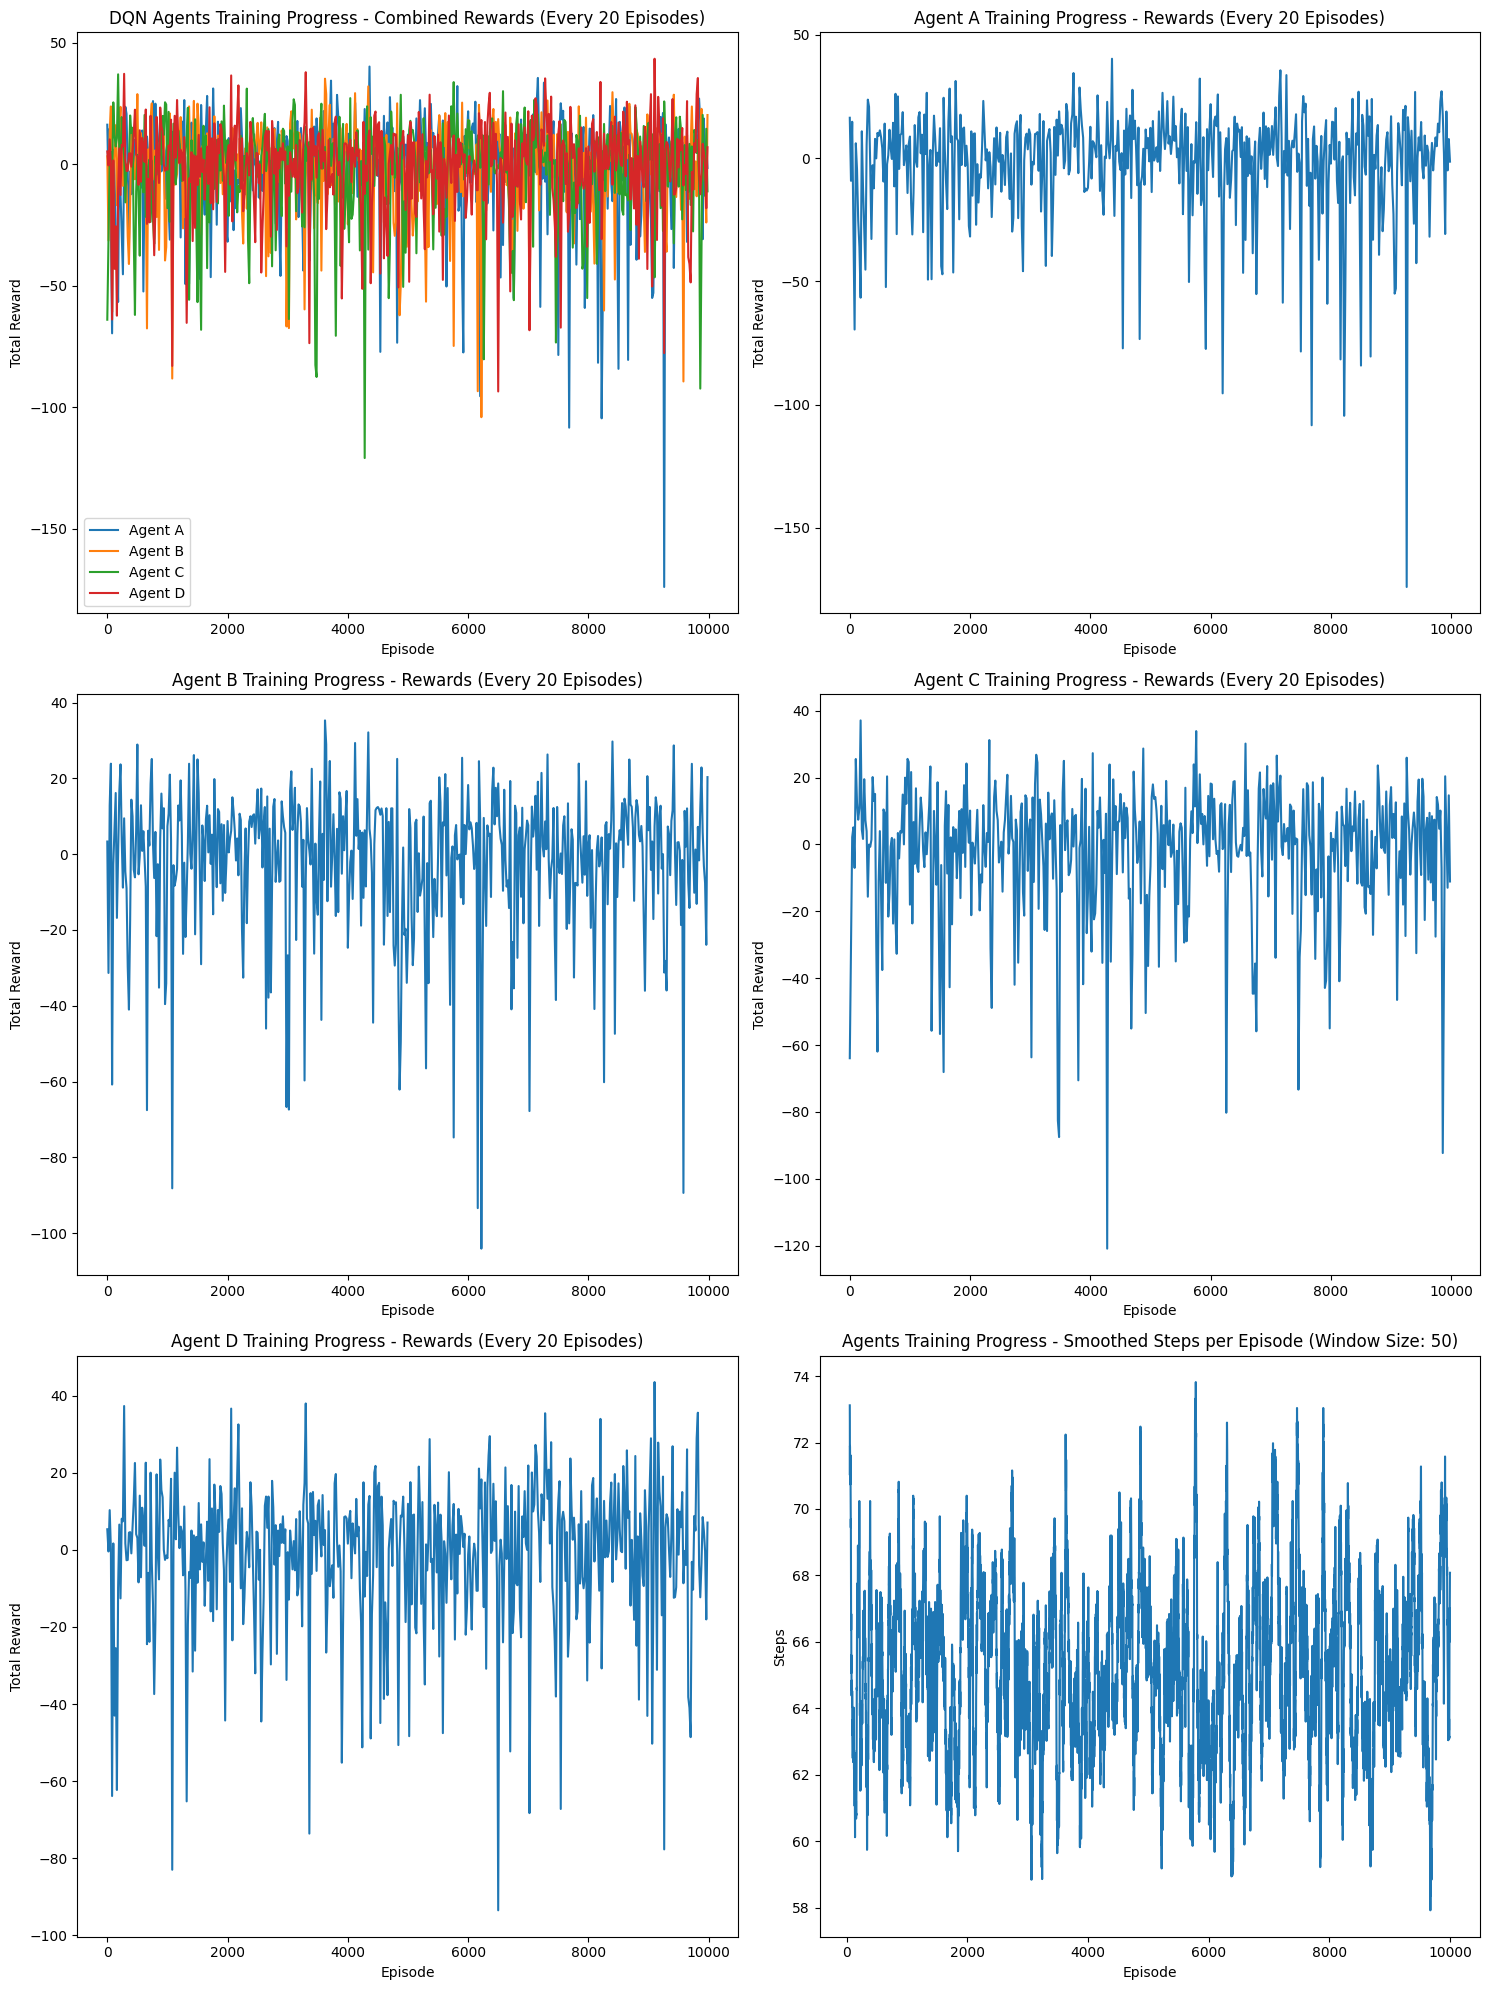

Data saved to random_results.csv


In [ ]:
from os import write
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output

def write_to_file(text):
    with open("game_log.txt", "w") as file:
        file.write(text)

def play_and_plot(env, num_episodes=10000, max_steps=500, step_threshold=500):
    steps_to_finish = []
    agents = [Random_Agent(name) for name in ['A', 'B', 'C', 'D']]
    agent_rewards = {name: [] for name in ['A', 'B', 'C', 'D']}  # Initialize rewards tracking

    for episode in range(num_episodes):
        episode_rewards = {name: 0 for name in ['A', 'B', 'C', 'D']}  # Initialize episode rewards for each agent
        obs, _ = env.reset()
        for step in range(max_steps):
            current_agent = agents[env.current_player_index]
            action = current_agent.choose_action(env)
            obs, step_rewards, done, _, info = env.step(action)

            # Update agent-specific rewards
            agent_name = current_agent.name
            episode_rewards[agent_name] += step_rewards[agent_name]

            if done:
                steps_to_finish.append(step + 1)
                break

            if step > step_threshold:
                print("Step threshold exceeded. Stopping execution. Total steps is " + str(step) + " Logging game ...")

                # Optionally, you can log or save the rewards here if needed
                # For now, just breaking the loop
                return

        # Append episode rewards to the respective agent's reward list
        for name in agent_rewards:
            agent_rewards[name].append(episode_rewards[name])

    # You can save or plot the agent-specific rewards here
    plot_agent_progress_2(agent_rewards, steps_to_finish, num_episodes)
    random_df = save_data_to_csv(agent_rewards, steps_to_finish, "random")
    env.close()
env = ChipGameEnv()
play_and_plot(env, num_episodes=10000)

In [ ]:
# from keras.models import Sequential
# from keras.layers import Dense


def plot_agent_progress(agent_rewards, steps_per_episode, num_episodes):
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))  # Create subplots

    # Plot agent rewards
    for agent_name, rewards in agent_rewards.items():
        axs[0].plot(range(num_episodes), rewards, label=f'Agent {agent_name}')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Total Reward')
    axs[0].set_title('DQN Agents Training Progress - Rewards')
    axs[0].legend()

    # Plot steps per episode
    axs[1].plot(range(num_episodes), steps_per_episode)
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Steps')
    axs[1].set_title('DQN Agents Training Progress - Steps per Episode')

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

# Collect rewards and plot progress
agent_rewards = {'A': [], 'B': [], 'C': [], 'D': []}
steps_per_episode = []

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Add, Subtract, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
import numpy as np
import random
from IPython.display import clear_output
import matplotlib.pyplot as plt

class BaseAgent:
    def __init__(self, name, state_size, action_size, **kwargs):
        self.name = name
        self.state_size = state_size
        self.action_size = action_size
        self.memory = []
        self.gamma = kwargs.get('gamma', 0.95)
        self.epsilon = kwargs.get('epsilon', 1.0)
        self.epsilon_min = kwargs.get('epsilon_min', 0.01)
        self.epsilon_decay = kwargs.get('epsilon_decay', 0.995)
        self.learning_rate = kwargs.get('learning_rate', 0.001)
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential([
            Dense(64, activation='relu', input_shape=(self.state_size,)),
            Dense(64, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done, steps):
        self.memory.append((state, action, reward, next_state, done, steps))

    @tf.function
    def act(self, state, env_state):
        if tf.random.uniform(()) <= self.epsilon:
            return self.choose_random_action(env_state)
        else:
            act_values = self.model(state)
            return self.choose_best_action(act_values, env_state)

    def choose_random_action(self, env_state):
        if env_state == "choose_pile":
            return tf.random.uniform((), maxval=6, dtype=tf.int64)  # Assuming 6 rows
        else:
            return tf.random.uniform((), minval=6, maxval=self.action_size, dtype=tf.int64)

    def choose_best_action(self, act_values, env_state):
        if env_state == "choose_pile":
            return tf.cast(tf.argmax(act_values[0][:6]), tf.int64)  # Assuming 6 rows
        else:
            return tf.cast(tf.argmax(act_values[0][6:]) + 6, tf.int64)

    def replay(self, batch_size):
        # This method will be implemented in child classes
        pass

    def load(self, name):
        self.model.load_weights(name)

    def save(self, name):
        self.model.save_weights(name)


In [ ]:

class DQNAgent(BaseAgent):
    def __init__(self, name, state_size, action_size, **kwargs):
        kwargs.setdefault('gamma', 0.95)
        kwargs.setdefault('epsilon', 0.5)
        kwargs.setdefault('epsilon_min', 0.01)
        kwargs.setdefault('epsilon_decay', 0.995)
        kwargs.setdefault('learning_rate', 0.001)
        super().__init__(name, state_size, action_size, **kwargs)

    @tf.function
    def replay(self, states, actions, rewards, next_states, dones):
        with tf.GradientTape() as tape:
            targets = self.model(states)
            next_q_values = self.target_model(next_states)
            max_next_q = tf.reduce_max(next_q_values, axis=1)

            updates = rewards + (1.0 - tf.cast(dones, tf.float32)) * self.gamma * max_next_q
            indices = tf.stack([tf.range(tf.shape(actions)[0]), tf.cast(actions, tf.int32)], axis=1)
            targets_full = tf.tensor_scatter_nd_update(targets, indices, updates)

            loss = tf.reduce_mean(tf.square(targets_full - self.model(states)))

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.model.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return loss


In [ ]:

class DDQNAgent(BaseAgent):
    def __init__(self, name, state_size, action_size, **kwargs):
        kwargs.setdefault('gamma', 0.99)
        kwargs.setdefault('epsilon', 0.5)
        kwargs.setdefault('epsilon_min', 0.05)
        kwargs.setdefault('epsilon_decay', 0.99)
        kwargs.setdefault('learning_rate', 0.0005)
        super().__init__(name, state_size, action_size, **kwargs)

    @tf.function
    def replay(self, states, actions, rewards, next_states, dones):
        with tf.GradientTape() as tape:
            targets = self.model(states)
            next_actions = tf.argmax(self.model(next_states), axis=1)
            next_q_values = self.target_model(next_states)
            next_q = tf.gather(next_q_values, next_actions, batch_dims=1)

            updates = rewards + (1.0 - tf.cast(dones, tf.float32)) * self.gamma * next_q
            indices = tf.stack([tf.range(tf.shape(actions)[0]), tf.cast(actions, tf.int32)], axis=1)
            targets_full = tf.tensor_scatter_nd_update(targets, indices, updates)

            loss = tf.reduce_mean(tf.square(targets_full - self.model(states)))

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.model.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return loss


In [ ]:

class MeanLayer(Layer):
    def __init__(self, axis=None, keepdims=False, **kwargs):
        super(MeanLayer, self).__init__(**kwargs)
        self.axis = axis
        self.keepdims = keepdims

    def call(self, x):
        return tf.reduce_mean(x, axis=self.axis, keepdims=self.keepdims)

class DuelingDQNAgent(BaseAgent):
    def __init__(self, name, state_size, action_size, **kwargs):
        kwargs.setdefault('gamma', 0.99)
        kwargs.setdefault('epsilon', 0.5)
        kwargs.setdefault('epsilon_min', 0.1)
        kwargs.setdefault('epsilon_decay', 0.995)
        kwargs.setdefault('learning_rate', 0.00025)
        super().__init__(name, state_size, action_size, **kwargs)

    def _build_model(self):
        input_layer = Input(shape=(self.state_size,))
        shared = Dense(64, activation='relu')(input_layer)
        shared = Dense(64, activation='relu')(shared)

        value_stream = Dense(32, activation='relu')(shared)
        value = Dense(1)(value_stream)

        advantage_stream = Dense(32, activation='relu')(shared)
        advantage = Dense(self.action_size)(advantage_stream)

        advantage_mean = MeanLayer(axis=1, keepdims=True)(advantage)
        output = Add()([value, Subtract()([advantage, advantage_mean])])

        model = Model(inputs=input_layer, outputs=output)
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    @tf.function
    def replay(self, states, actions, rewards, next_states, dones):
        with tf.GradientTape() as tape:
            targets = self.model(states)
            next_q_values = self.target_model(next_states)
            max_next_q = tf.reduce_max(next_q_values, axis=1)

            updates = rewards + (1.0 - tf.cast(dones, tf.float32)) * self.gamma * max_next_q
            indices = tf.stack([tf.range(tf.shape(actions)[0]), tf.cast(actions, tf.int32)], axis=1)
            targets_full = tf.tensor_scatter_nd_update(targets, indices, updates)

            loss = tf.reduce_mean(tf.square(targets_full - self.model(states)))

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.model.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return loss


In [ ]:
class A2CAgent(BaseAgent):
    def __init__(self, name, state_size, action_size, **kwargs):
        super().__init__(name, state_size, action_size, **kwargs)
        self.actor, self.critic = self._build_actor_critic()

    def _build_actor_critic(self):
        input_state = Input(shape=(self.state_size,))
        dense1 = Dense(16, activation='relu')(input_state)
        dense2 = Dense(16, activation='relu')(dense1)

        actor_output = Dense(self.action_size, activation='softmax')(dense2)
        critic_output = Dense(1)(dense2)

        actor = Model(inputs=input_state, outputs=actor_output)
        critic = Model(inputs=input_state, outputs=critic_output)

        actor.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='categorical_crossentropy')
        critic.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')

        return actor, critic

    def act(self, state, env_state):
        if np.random.rand() <= self.epsilon:
            return self.choose_random_action(env_state)

        policy = self.actor.predict(state, verbose=0)[0]
        if env_state == "choose_pile":
            return np.argmax(policy[:6])
        else:
            return np.argmax(policy[6:]) + 6

    def replay(self, states, actions, rewards, next_states, dones):
        values = self.critic.predict(states, verbose=0)
        next_values = self.critic.predict(next_states, verbose=0)

        advantages = rewards + self.gamma * next_values * (1 - dones) - values

        actor_targets = tf.one_hot(actions, self.action_size)
        self.actor.train_on_batch(states, actor_targets, sample_weight=advantages)
        self.critic.train_on_batch(states, rewards + self.gamma * next_values * (1 - dones))

    def update_target_model(self):
        # A2C doesn't use a target model, so this method can be empty or just pass
        pass

    def load(self, name):
        self.actor.load_weights(f"_actor{name}")
        self.critic.load_weights(f"_critic{name}")

    def save(self, name):
        self.actor.save_weights(f"_actor{name}")
        self.critic.save_weights(f"_critic{name}")

    def choose_random_action(self, env_state):
        if env_state == "choose_pile":
            return np.random.randint(0, 6)  # Assuming 6 rows
        else:
            return np.random.randint(6, self.action_size)


In [ ]:
class A3CAgent:
    def __init__(self, name, state_size, action_size, **kwargs):
        self.name = name
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = kwargs.get('gamma', 0.99)
        self.learning_rate = kwargs.get('learning_rate', 0.001)
        self.epsilon = kwargs.get('epsilon', 1.0)
        self.epsilon_decay = kwargs.get('epsilon_decay', 0.995)
        self.epsilon_min = kwargs.get('epsilon_min', 0.01)
        self.memory = []
        self.actor, self.critic = self._build_actor_critic()
        self.optimizer = Adam(learning_rate=self.learning_rate)

    def _build_actor_critic(self):
        input_state = Input(shape=(self.state_size,))
        dense1 = Dense(64, activation='relu')(input_state)
        dense2 = Dense(64, activation='relu')(dense1)

        actor_output = Dense(self.action_size, activation='softmax')(dense2)
        critic_output = Dense(1)(dense2)

        actor = Model(inputs=input_state, outputs=actor_output)
        critic = Model(inputs=input_state, outputs=critic_output)

        return actor, critic

    def act(self, state, env_state):
        if np.random.rand() <= self.epsilon:
            if env_state == "choose_pile":
                return np.random.randint(0, 6)
            else:
                return np.random.randint(6, self.action_size)

        policy = self.actor.predict(state, verbose=0)[0]
        if env_state == "choose_pile":
            return np.argmax(policy[:6])
        else:
            return np.argmax(policy[6:]) + 6

    def remember(self, state, action, reward, next_state, done, steps):
        self.memory.append((state, action, reward, next_state, done, steps))

    def replay(self, states, actions, rewards, next_states, dones):
        with tf.GradientTape() as tape:
            policy = self.actor(states)
            values = self.critic(states)
            next_values = self.critic(next_states)

            advantages = rewards + self.gamma * next_values * (1 - dones) - values

            actor_loss = self._actor_loss(policy, actions, advantages)
            critic_loss = tf.reduce_mean(tf.square(advantages))

            total_loss = actor_loss + critic_loss

        grads = tape.gradient(total_loss, self.actor.trainable_variables + self.critic.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.actor.trainable_variables + self.critic.trainable_variables))

    def _actor_loss(self, policy, actions, advantages):
        action_probs = tf.gather(policy, actions, batch_dims=1)
        log_probs = tf.math.log(action_probs)
        return -tf.reduce_mean(log_probs * advantages)

    def update_target_model(self):
        # A3C doesn't use a target model, so this method can be empty
        pass

    def load(self, name):
        self.actor.load_weights(f"{name}_actor")
        self.critic.load_weights(f"{name}_critic")

    def save(self, name):
        self.actor.save_weights(f"{name}_actor")
        self.critic.save_weights(f"{name}_critic")

class Agent:
    def __init__(self, name, shared_agent):
        self.name = name
        self.shared_agent = shared_agent

    def act(self, state, env_state):
        return self.shared_agent.act(state, env_state)

In [ ]:
class PPOAgent:
    def __init__(self, name, state_size, action_size, **kwargs):
        self.name = name
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = kwargs.get('gamma', 0.99)
        self.learning_rate = kwargs.get('learning_rate', 0.0003)
        self.epsilon = kwargs.get('epsilon', 0.2)
        self.epsilon_decay = kwargs.get('epsilon_decay', 0.995)
        self.epsilon_min = kwargs.get('epsilon_min', 0.01)
        self.clip_ratio = kwargs.get('clip_ratio', 0.2)
        self.memory = []
        self.actor, self.critic = self._build_actor_critic()
        self.optimizer = Adam(learning_rate=self.learning_rate)

    def _build_actor_critic(self):
        input_state = Input(shape=(self.state_size,))
        dense1 = Dense(64, activation='relu')(input_state)
        dense2 = Dense(64, activation='relu')(dense1)

        actor_output = Dense(self.action_size, activation='softmax')(dense2)
        critic_output = Dense(1)(dense2)

        actor = Model(inputs=input_state, outputs=actor_output)
        critic = Model(inputs=input_state, outputs=critic_output)

        return actor, critic

    def act(self, state, env_state):
        if np.random.rand() <= self.epsilon:
            if env_state == "choose_pile":
                return np.random.randint(0, 6)
            else:
                return np.random.randint(6, self.action_size)

        policy = self.actor.predict(state, verbose=0)[0]
        if env_state == "choose_pile":
            return np.argmax(policy[:6])
        else:
            return np.argmax(policy[6:]) + 6

    def remember(self, state, action, reward, next_state, done, steps):
        self.memory.append((state, action, reward, next_state, done, steps))

    def replay(self, states, actions, rewards, next_states, dones):
        old_probs = self.actor.predict(states, verbose=0)
        old_values = self.critic.predict(states, verbose=0)

        advantages = rewards + self.gamma * self.critic.predict(next_states, verbose=0) * (1 - dones) - old_values
        advantages = (advantages - np.mean(advantages)) / (np.std(advantages) + 1e-8)

        for _ in range(10):  # Number of optimization epochs
            with tf.GradientTape() as tape:
                new_probs = self.actor(states)
                new_values = self.critic(states)

                ratio = tf.exp(tf.math.log(tf.gather(new_probs, actions, batch_dims=1) + 1e-10) -
                               tf.math.log(tf.gather(old_probs, actions, batch_dims=1) + 1e-10))

                min_advantage = tf.where(
                    advantages > 0,
                    (1 + self.clip_ratio) * advantages,
                    (1 - self.clip_ratio) * advantages,
                )

                actor_loss = -tf.reduce_mean(tf.minimum(ratio * advantages, min_advantage))
                critic_loss = tf.reduce_mean(tf.square(rewards + self.gamma * self.critic.predict(next_states, verbose=0) * (1 - dones) - new_values))

                total_loss = actor_loss + 0.5 * critic_loss

            grads = tape.gradient(total_loss, self.actor.trainable_variables + self.critic.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.actor.trainable_variables + self.critic.trainable_variables))

    def update_target_model(self):
        # PPO doesn't use a target model, so this method can be empty
        pass

    def load(self, name):
        self.actor.load_weights(f"{name}_actor")
        self.critic.load_weights(f"{name}_critic")

    def save(self, name):
        self.actor.save_weights(f"{name}_actor")
        self.critic.save_weights(f"{name}_critic")

class Agent:
    def __init__(self, name, shared_agent):
        self.name = name
        self.shared_agent = shared_agent

    def act(self, state, env_state):
        return self.shared_agent.act(state, env_state)

In [ ]:

class Agent:
    def __init__(self, name, shared_agent):
        self.name = name
        self.shared_agent = shared_agent

    def act(self, state, env_state):
        return self.shared_agent.act(state, env_state)


In [ ]:

def play_game_with_agents(env, agent_type, num_episodes=1000, max_steps=200, batch_size=32, **agent_params):
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    if agent_type == "DQN":
        AgentClass = DQNAgent
    elif agent_type == "DDQN":
        AgentClass = DDQNAgent
    elif agent_type == "DuelingDQN":
        AgentClass = DuelingDQNAgent
    elif agent_type == "A2C":
        AgentClass = A2CAgent
    elif agent_type == "A3C":
        AgentClass = A3CAgent
    elif agent_type == "PPO":
        AgentClass = PPOAgent
    else:
        raise ValueError("Invalid agent type")

    # Create a single shared agent
    shared_agent = AgentClass("Shared", state_size, action_size, **agent_params)

    # Create individual agents that use the shared network
    agents = [Agent(name, shared_agent) for name in ['A', 'B', 'C', 'D']]

    steps_per_episode = []
    agent_rewards = {name: [] for name in ['A', 'B', 'C', 'D']}

    for episode in range(num_episodes):
        obs, _ = env.reset()
        obs = np.reshape(obs, [1, state_size])
        total_rewards = {agent.name: 0 for agent in agents}

        for step in range(max_steps):
            current_agent = agents[env.current_player_index]
            action = current_agent.act(tf.convert_to_tensor(obs, dtype=tf.float32), env.state)
            next_obs, step_rewards, done, _, info = env.step(action)
            next_obs = np.reshape(next_obs, [1, state_size])

            reward = step_rewards[current_agent.name]
            shared_agent.remember(obs, action, reward, next_obs, done, env.steps_num)
            obs = next_obs

            for agent in agents:
                total_rewards[agent.name] += step_rewards[agent.name]

            if len(shared_agent.memory) > batch_size and step%10 == 0:
                minibatch = random.sample(shared_agent.memory, batch_size)
                states = tf.convert_to_tensor(np.array([t[0] for t in minibatch]).reshape(-1, state_size), dtype=tf.float32)
                actions = tf.convert_to_tensor(np.array([t[1] for t in minibatch]), dtype=tf.int64)
                rewards = tf.convert_to_tensor(np.array([t[2] for t in minibatch]), dtype=tf.float32)
                next_states = tf.convert_to_tensor(np.array([t[3] for t in minibatch]).reshape(-1, state_size), dtype=tf.float32)
                dones = tf.convert_to_tensor(np.array([t[4] for t in minibatch]), dtype=tf.float32)

                shared_agent.replay(states, actions, rewards, next_states, dones)

            if step % 10 == 0:
                clear_output(wait=True)
                print(f"{agent_type} Agents -> Episode: {episode}/{num_episodes}, progress: {episode/num_episodes}")

            if done:
                steps_per_episode.append(step + 1)
                break

        for agent in agents:
            agent_rewards[agent.name].append(total_rewards[agent.name])

        shared_agent.epsilon = max(shared_agent.epsilon * shared_agent.epsilon_decay, shared_agent.epsilon_min)

        if episode % 500 == 0:
            shared_agent.save(f"shared_{agent_type}.weights.h5")
            shared_agent.update_target_model()

    plot_agent_progress_2(agent_rewards, steps_per_episode, num_episodes)
    df = save_data_to_csv(agent_rewards, steps_per_episode, agent_type)
    env.close()


In [ ]:
env = ChipGameEnv()

Pygame initialized


In [ ]:
#Train with A2C agents
# play_game_with_agents(env, "A2C", num_episodes=1000, learning_rate=0.001, epsilon_decay=0.99)

In [ ]:
#Train with A3C agents
# play_game_with_agents(env, "A3C", num_episodes=1000, learning_rate=0.0003, epsilon_decay=0.99)

In [ ]:
#Train with PPO agents
# play_game_with_agents(env, "PPO", num_episodes=1000, learning_rate=0.0003, epsilon_decay=0.99)

In [ ]:
# Train with DQN agents
# play_game_with_agents(env, "DQN", num_episodes=10000, learning_rate=0.001, epsilon_decay=0.995)

In [ ]:
# Train with DDQN agents
# play_game_with_agents(env, "DDQN", num_episodes=10000, learning_rate=0.0005, epsilon_decay=0.99)

In [ ]:
# Train with Dueling DQN agents
# play_game_with_agents(env, "DuelingDQN", num_episodes=10000, learning_rate=0.00025, epsilon_decay=0.995)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

def save_data_to_csv(agent_rewards, steps_to_finish, file_prefix):
    # Create a DataFrame in the desired format
    data = {
        "Episode": list(range(1, len(steps_to_finish) + 1)),
        "Agent_A": agent_rewards["A"],
        "Agent_B": agent_rewards["B"],
        "Agent_C": agent_rewards["C"],
        "Agent_D": agent_rewards["D"],
        "Steps_Per_Episode": steps_to_finish
    }

    df = pd.DataFrame(data)
    # Save to a CSV file
    file_name = f"{file_prefix}_results.csv"
    df.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")
    return df

def play_and_plot(env, num_episodes=10000, max_steps=500, step_threshold=500):
    steps_to_finish = []
    agents = [Random_Agent(name) for name in ['A', 'B', 'C', 'D']]
    agent_rewards = {name: [] for name in ['A', 'B', 'C', 'D']}  # Initialize rewards tracking

    for episode in range(num_episodes):
        episode_rewards = {name: 0 for name in ['A', 'B', 'C', 'D']}  # Initialize episode rewards for each agent
        obs, _ = env.reset()
        for step in range(max_steps):
            current_agent = agents[env.current_player_index]
            action = current_agent.choose_action(env)
            obs, step_rewards, done, _, info = env.step(action)

            # Update agent-specific rewards
            agent_name = current_agent.name
            episode_rewards[agent_name] += step_rewards[agent_name]

            if done:
                steps_to_finish.append(step + 1)
                break

            if step > step_threshold:
                print("Step threshold exceeded. Stopping execution. Total steps is " + str(step) + " Logging game ...")
                return

        # Append episode rewards to the respective agent's reward list
        for name in agent_rewards:
            agent_rewards[name].append(episode_rewards[name])

    # Save the results in a CSV file
    random_df = save_data_to_csv(agent_rewards, steps_to_finish, "random")
    env.close()

# Example usage
env = ChipGameEnv()  # Replace with your actual environment
play_and_plot(env, num_episodes=10000)


Pygame initialized


KeyboardInterrupt: 